# Limpieza de los datos 

In [5]:
import pandas as pd

In [6]:
df = pd.read_csv("dataset_incendios.csv")

In [7]:
def limpiar_datos(df):
    df['fecha'] = pd.to_datetime(df['fecha'])
    df['ndvi'] = df['ndvi'].fillna(df['ndvi'].mean())
    df = df[(df['temp'] > -10) & (df['temp'] < 50)]
    df = df[(df['humedad'] >= 0) & (df['humedad'] <= 100)]
    return df

In [8]:
df = limpiar_datos(df)

# Dataset version 1: variables basicas 

In [9]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148551 entries, 0 to 148550
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   fecha      148551 non-null  datetime64[ns]
 1   id_cvegeo  148551 non-null  int64         
 2   temp       148551 non-null  float64       
 3   humedad    148551 non-null  float64       
 4   lluvia     148551 non-null  float64       
 5   viento     148551 non-null  float64       
 6   ndvi       148551 non-null  float64       
 7   incendio   148551 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 9.1 MB


In [10]:
X = df[['temp','humedad','lluvia','viento','ndvi']]
y = df['incendio']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# MODELO 1: Arbol de decision 

In [12]:
from sklearn.tree import DecisionTreeClassifier

modelo = DecisionTreeClassifier(max_depth=5)
modelo.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

# Metricas de evaluacion 

In [13]:
from sklearn.metrics import classification_report

pred = modelo.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98     28381
           1       0.00      0.00      0.00      1330

    accuracy                           0.96     29711
   macro avg       0.48      0.50      0.49     29711
weighted avg       0.91      0.96      0.93     29711



/home/jimena/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/jimena/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/jimena/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Varibles con mayor influencia 

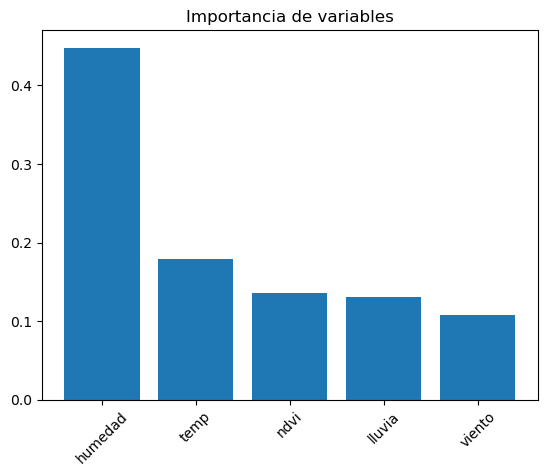

In [18]:
imp = pd.DataFrame({
    'variable': X.columns,
    'importancia': modelo_rf.feature_importances_
})

imp = imp.sort_values(by='importancia', ascending=False)

plt.bar(imp['variable'], imp['importancia'])
plt.xticks(rotation=45)
plt.title("Importancia de variables")
plt.show()

# Matriz de confusion 

In [19]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, pred_rf)

array([[18155, 10226],
       [  357,   973]])

# MODELO 2: Random Forest 

In [14]:
modelo_bal = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced'
)

modelo_bal.fit(X_train, y_train)

pred_bal = modelo_bal.predict(X_test)

print(classification_report(y_test, pred_bal))

              precision    recall  f1-score   support

           0       0.98      0.63      0.77     28381
           1       0.09      0.74      0.15      1330

    accuracy                           0.63     29711
   macro avg       0.53      0.69      0.46     29711
weighted avg       0.94      0.63      0.74     29711



In [15]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)

print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.98      0.64      0.77     28381
           1       0.09      0.73      0.16      1330

    accuracy                           0.64     29711
   macro avg       0.53      0.69      0.46     29711
weighted avg       0.94      0.64      0.75     29711



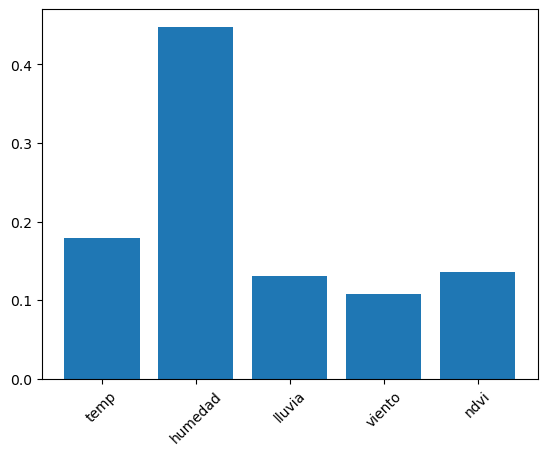

In [16]:
import matplotlib.pyplot as plt

importancias = modelo_rf.feature_importances_
nombres = X.columns

plt.bar(nombres, importancias)
plt.xticks(rotation=45)
plt.show()